<div align="center">

# Z-Score na Mineração de Dados
### Detecção de outliers e imputação de dados faltantes em vendas virtuais

**FATEC · 6º semestre · Mineração de Dados**

**Professor:** Carlos Feichas

</div>

**Integrantes:**

| | |
|---|---|
| Andre Salerno | Guilherme Benedito |
| Eric Lourenço | Brenno Rosa |
| Karen Gonçalves | Ivan Suiyama |

---

# Z-Score: breve histórico conceitual

O **z-score** (ou escore padrão) indica quantos desvios padrão um valor está afastado da média:

$$z = \frac{x - \mu}{\sigma}$$

Ele coloca dados de escalas diferentes numa mesma régua, o que o torna útil tanto em estatística quanto em mineração de dados.

## 1. Origens (séculos XVIII e XIX)
- A base é a **distribuição normal**, formalizada por De Moivre (1733), Laplace e principalmente **Gauss** (~1809), no estudo de erros de medição astronômica.
- A ideia central: muitos fenômenos se agrupam em torno de uma média com dispersão previsível.

## 2. Padronização (final do século XIX ao início do XX)
- **Karl Pearson** introduziu o termo *desvio padrão* (1894) e consolidou a estatística moderna.
- Surgiu a noção de medir a distância de um valor à média em unidades de desvio padrão, ou seja, o z-score.
- Isso permite comparar valores de escalas diferentes, como notas e alturas, em uma régua comum.

## 3. Popularização (século XX)
- As **tabelas da normal padrão (tabela Z)** viraram ferramenta clássica de testes de hipótese e intervalos de confiança.
- **Fisher**, Neyman e Pearson consolidaram a inferência estatística, e o z-score passou a ser a base do teste Z.
- Na psicometria e na educação, ele deu origem a escalas derivadas, como QI, T-score e notas padronizadas.

## 4. Uso industrial e financeiro
- **Controle estatístico de processos** (Shewhart, anos 1920): os limites de controle de ±3σ são, na prática, z-scores.
- Em 1968, **Edward Altman** criou o "Altman Z-Score", que prevê falência de empresas. O nome é parecido, mas é um modelo distinto, que combina índices financeiros.

## 5. Era da mineração de dados e do machine learning
- O z-score virou técnica-padrão de **pré-processamento** (padronização de atributos, como o `StandardScaler`). Ele evita que variáveis de escala maior dominem algoritmos baseados em distância ou gradiente, como KNN, K-Means, SVM e regressão.
- Também é muito usado na **detecção de outliers**: valores com |z| > 3 (ou 2,5) costumam ser tratados como atípicos.

## 6. Limitações reconhecidas
- Assume distribuição aproximadamente normal.
- Média e desvio padrão são sensíveis a outliers. Isso motivou alternativas, como o **z-score modificado** (baseado na mediana e no MAD, de Iglewicz e Hoaglin, 1993) e a normalização robusta.

## 7. Tratamento dos dados

### Dicionário de dados

Base `trabalho-vendas-virtuais.csv` (convertida da planilha `trabalho-vendas-virtuais.xlsx`, aba `Base_Vendas`): 60 pedidos de vendas online, de 03/01/2026 a 01/05/2026, com 12 colunas.

| Coluna | Tipo | Descrição | Valores / observações |
|---|---|---|---|
| `ID_Pedido` | inteiro | Identificador único do pedido | 1001 a 1060 |
| `Data_Pedido` | data | Data em que o pedido foi feito | 03/01/2026 a 01/05/2026 |
| `Categoria` | texto | Categoria do produto vendido | Eletrônicos, Casa, Moda, Beleza, Esportes, Livros (10 pedidos cada) |
| `Região` | texto | Região do Brasil de destino da entrega | Sudeste, Nordeste, Norte, Sul, Centro-Oeste |
| `Forma_Pagamento` | texto | Meio de pagamento usado | Cartão de crédito, PIX, Boleto, Carteira digital. **1 faltante** |
| `Quantidade` | inteiro | Número de unidades compradas no pedido | 1 a 40 |
| `Preço_Unitário` | decimal | Preço de uma unidade, em R$ | 49,90 a 4.999,90. **1 faltante** |
| `Desconto_Pct` | decimal | Desconto aplicado, como fração (0,05 = 5%) | 0, 0,05, 0,10, 0,15 e 0,55 |
| `Frete` | decimal | Valor do frete, em R$ | 0, 12,90, 18,50 e 24,90 |
| `Prazo_Entrega_Dias` | decimal | Prazo de entrega, em dias | 2 a 40. **1 faltante** |
| `Valor_Total` | decimal | Valor final do pedido, em R$ | `Quantidade × Preço_Unitário × (1 − Desconto_Pct) + Frete`. **1 faltante** |
| `Situação_Anormal` | texto | Rótulo indicando se o pedido é normal ou uma anomalia inserida na base | Normal (56 pedidos) ou 4 tipos de anomalia (1 pedido cada): quantidade extrema, preço extremo, atraso extremo e combinada (quantidade alta + desconto alto + frete zero) |

> A coluna `Situação_Anormal` não entra nos cálculos: usamos apenas para conferir se o z-score encontra as anomalias.

In [1]:
import sys; print(sys.executable)


/home/ivan/miniforge3/bin/python3


In [2]:
import pandas as pd

df_vdas_vrt = pd.read_csv("trabalho-vendas-virtuais.csv", parse_dates=["Data_Pedido"])

print(df_vdas_vrt.head(10))

   ID_Pedido Data_Pedido    Categoria        Região    Forma_Pagamento  \
0       1001  2026-01-03  Eletrônicos       Sudeste  Cartão de crédito   
1       1002  2026-01-05         Casa      Nordeste                PIX   
2       1003  2026-01-07         Moda         Norte             Boleto   
3       1004  2026-01-09       Beleza           Sul   Carteira digital   
4       1005  2026-01-11     Esportes  Centro-Oeste  Cartão de crédito   
5       1006  2026-01-13       Livros       Sudeste                PIX   
6       1007  2026-01-15  Eletrônicos      Nordeste             Boleto   
7       1008  2026-01-17         Casa         Norte   Carteira digital   
8       1009  2026-01-19         Moda           Sul  Cartão de crédito   
9       1010  2026-01-21       Beleza  Centro-Oeste                PIX   

   Quantidade  Preço_Unitário  Desconto_Pct  Frete  Prazo_Entrega_Dias  \
0           1            79.9          0.00    0.0                 2.0   
1           2           139.9        

In [3]:
df_vdas_vrt.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID_Pedido           60 non-null     int64         
 1   Data_Pedido         60 non-null     datetime64[us]
 2   Categoria           60 non-null     str           
 3   Região              60 non-null     str           
 4   Forma_Pagamento     59 non-null     str           
 5   Quantidade          60 non-null     int64         
 6   Preço_Unitário      59 non-null     float64       
 7   Desconto_Pct        60 non-null     float64       
 8   Frete               60 non-null     float64       
 9   Prazo_Entrega_Dias  59 non-null     float64       
 10  Valor_Total         59 non-null     float64       
 11  Situação_Anormal    60 non-null     str           
dtypes: datetime64[us](1), float64(5), int64(2), str(4)
memory usage: 5.8 KB


In [4]:
# nome colunas

df_vdas_vrt.columns

Index(['ID_Pedido', 'Data_Pedido', 'Categoria', 'Região', 'Forma_Pagamento',
       'Quantidade', 'Preço_Unitário', 'Desconto_Pct', 'Frete',
       'Prazo_Entrega_Dias', 'Valor_Total', 'Situação_Anormal'],
      dtype='str')

In [5]:
# quantidade de linhas e colunas
df_vdas_vrt.shape

(60, 12)

In [6]:
#breves estatísticas
df_vdas_vrt.describe()

,ID_Pedido,Data_Pedido,Quantidade,Preço_Unitário,Desconto_Pct,Frete,Prazo_Entrega_Dias,Valor_Total
count,60.000000,60,60.000000,59.000000,60.000000,60.000000,59.000000,59.000000
mean,1030.500000,2026-03-03 00:00:00,4.333333,219.730508,0.081667,13.660000,7.050847,725.389661
min,1001.000000,2026-01-03 00:00:00,1.000000,49.900000,0.000000,0.000000,2.000000,79.900000
25%,1015.750000,2026-02-01 12:00:00,2.000000,74.900000,0.037500,0.000000,4.000000,278.615000
50%,1030.500000,2026-03-03 00:00:00,4.000000,99.900000,0.075000,12.900000,7.000000,330.560000
75%,1045.250000,2026-04-01 12:00:00,5.000000,199.900000,0.112500,18.500000,9.000000,749.700000
max,1060.000000,2026-05-01 00:00:00,40.000000,4999.900000,0.550000,24.900000,40.000000,13518.230000
std,17.464249,NaN,5.316003,637.050021,0.082835,9.310377,5.247080,1742.135445


In [7]:
# colunas com dados faltantes
faltantes = df_vdas_vrt.isna().sum()
faltantes = faltantes[faltantes > 0].to_frame("qtd_faltantes")
faltantes["pct_faltantes %"] = (faltantes["qtd_faltantes"] / len(df_vdas_vrt) * 100).round(2)

faltantes

,qtd_faltantes,pct_faltantes %
Forma_Pagamento,1,1.67
Preço_Unitário,1,1.67
Prazo_Entrega_Dias,1,1.67
Valor_Total,1,1.67


In [8]:
# linhas que possuem algum dado faltante
df_vdas_vrt[df_vdas_vrt.isna().any(axis=1)]

,ID_Pedido,Data_Pedido,Categoria,Região,Forma_Pagamento,Quantidade,Preço_Unitário,Desconto_Pct,Frete,Prazo_Entrega_Dias,Valor_Total,Situação_Anormal
19,1020,2026-02-10,Casa,Centro-Oeste,Carteira digital,2,NaN,0.15,24.9,9.0,NaN,Normal
35,1036,2026-03-14,Livros,Sudeste,NaN,6,69.9,0.15,24.9,7.0,381.39,Normal
48,1049,2026-04-09,Eletrônicos,Sul,Cartão de crédito,1,79.9,0.00,0.0,NaN,79.90,Normal


### Z-score por categoria para identificar outliers antes da imputação

Antes de calcular a média que vai preencher os faltantes, aplicamos o z-score **dentro de cada categoria** para localizar valores extremos, que distorceriam essa média.

$$z = \frac{x - \bar{x}_{categoria}}{s_{categoria}}$$

Cada categoria tem apenas 10 pedidos. Com esse tamanho, o z-score máximo possível é ≈ 2,85, então o limite clássico de |z| > 3 nunca dispararia. Os gráficos abaixo ajudam a escolher o limite.

In [9]:
colunas_z = ["Quantidade", "Preço_Unitário", "Desconto_Pct", "Frete", "Prazo_Entrega_Dias", "Valor_Total"]

# z-score dentro de cada categoria (NaN é ignorado no cálculo da média e do desvio padrão)
df_z = df_vdas_vrt.groupby("Categoria")[colunas_z].transform(lambda s: (s - s.mean()) / s.std())

# quantos valores seriam marcados como outlier em cada limite
limites = [2, 2.5, 3]
pd.DataFrame({f"|z| > {l}": (df_z.abs() > l).sum() for l in limites})

,|z| > 2,|z| > 2.5,|z| > 3
Quantidade,2,2,0
Preço_Unitário,1,1,0
Desconto_Pct,1,1,0
Frete,0,0,0
Prazo_Entrega_Dias,1,1,0
Valor_Total,3,3,0


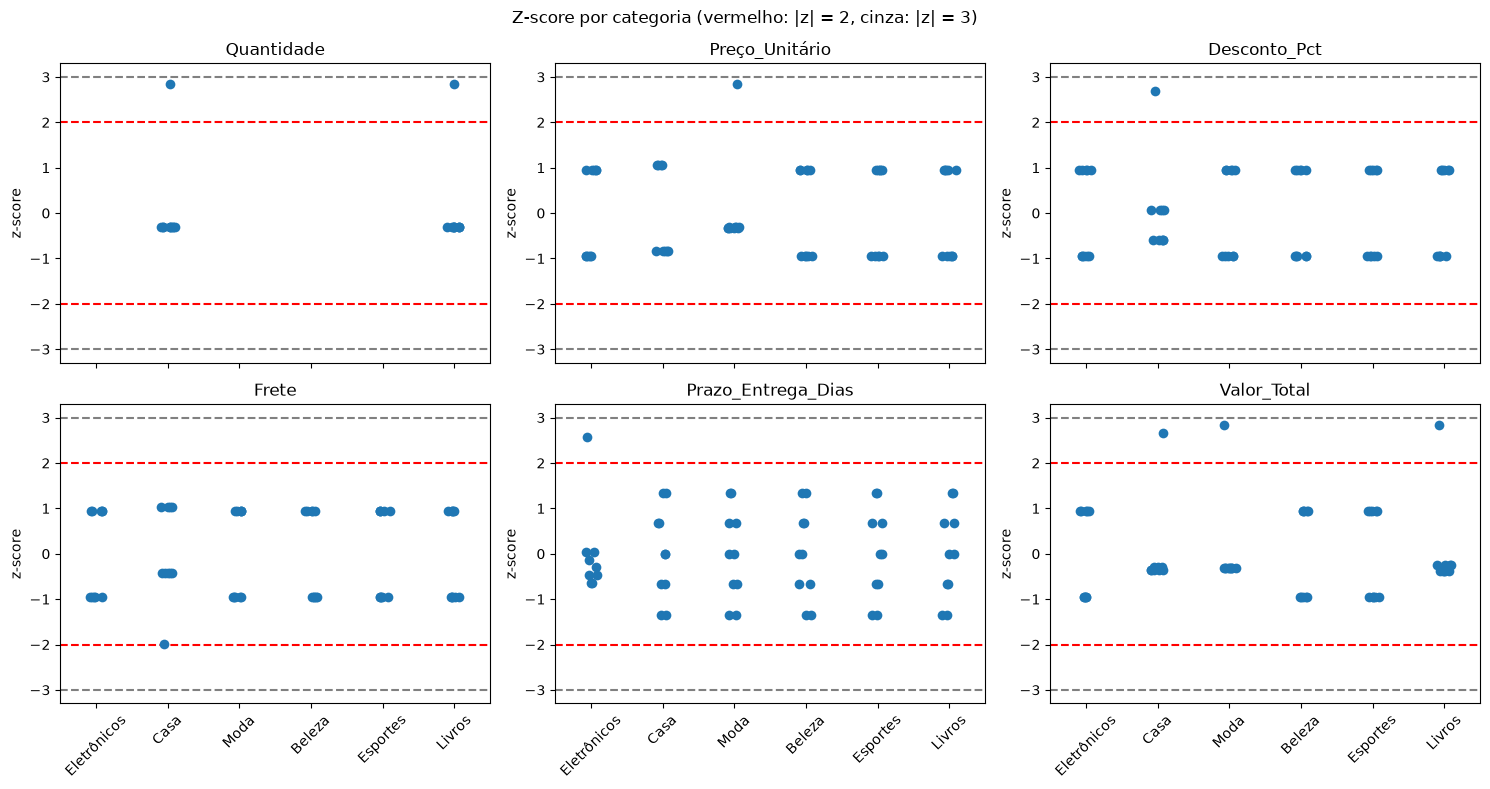

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# z-score de cada pedido por categoria; linha vermelha = |z| = 2, linha cinza = |z| = 3
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, col in zip(axes.flat, colunas_z):
    sns.stripplot(x=df_vdas_vrt["Categoria"], y=df_z[col], ax=ax, size=7)
    for lim, cor in [(2, "red"), (3, "gray")]:
        ax.axhline(lim, color=cor, ls="--")
        ax.axhline(-lim, color=cor, ls="--")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("z-score")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Z-score por categoria (vermelho: |z| = 2, cinza: |z| = 3)")
plt.tight_layout()
plt.show()

In [11]:
# limite escolhido: |z| > 2 (com 10 pedidos por categoria, |z| > 3 não detecta nada)
LIMITE_Z = 2
mask_outlier = df_z.abs() > LIMITE_Z

# pedidos com algum valor outlier, ao lado da coluna Situação_Anormal para conferência
df_vdas_vrt.loc[mask_outlier.any(axis=1), ["ID_Pedido", "Categoria", "Situação_Anormal"]].join(df_z.round(2))

,ID_Pedido,Categoria,Situação_Anormal,Quantidade,Preço_Unitário,Desconto_Pct,Frete,Prazo_Entrega_Dias,Valor_Total
11,1012,Livros,Anomalia: quantidade extrema,2.85,0.95,0.95,0.95,-0.67,2.84
26,1027,Moda,Anomalia: preço extremo,NaN,2.85,0.95,0.95,1.34,2.85
42,1043,Eletrônicos,Anomalia: atraso extremo,NaN,0.95,0.95,0.95,2.58,0.95
55,1056,Casa,Anomalia combinada: quantidade alta + desconto...,2.85,1.05,2.69,-1.98,0.00,2.67


In [12]:
# comparação das médias por categoria: antes (todos os valores) x depois (sem os outliers do z-score)
colunas_imputadas = ["Preço_Unitário", "Prazo_Entrega_Dias", "Valor_Total"]

media_antes = df_vdas_vrt.groupby("Categoria")[colunas_imputadas].mean()
media_depois = df_vdas_vrt[colunas_imputadas].mask(mask_outlier[colunas_imputadas]).groupby(df_vdas_vrt["Categoria"]).mean()

comparativo = pd.concat(
    {"Média antes": media_antes.stack(), "Média depois": media_depois.stack()},
    axis=1,
)
comparativo["Diferença"] = comparativo["Média depois"] - comparativo["Média antes"]
comparativo["Variação %"] = comparativo["Diferença"] / comparativo["Média antes"] * 100
comparativo.index.names = ["Categoria", "Coluna"]

comparativo.round(2)

Média antes  Média depois  Diferença  \
Categoria   Coluna                                                     
Beleza      Preço_Unitário            79.90         79.90       0.00   
            Prazo_Entrega_Dias         7.00          7.00       0.00   
            Valor_Total              304.54        304.54       0.00   
Casa        Preço_Unitário           148.79        148.79       0.00   
            Prazo_Entrega_Dias         7.00          7.00       0.00   
            Valor_Total              397.66        285.47    -112.19   
Eletrônicos Preço_Unitário            89.90         89.90       0.00   
            Prazo_Entrega_Dias         9.56          5.75      -3.81   
            Valor_Total               94.16         94.16       0.00   
Esportes    Preço_Unitário           199.90        199.90       0.00   
            Prazo_Entrega_Dias         6.00          6.00       0.00   
            Valor_Total              956.28        956.28       0.00   
Livros      Preço_Unitário            59.90         59.90       0.00   
            Prazo_Entrega_Dias         7.00          7.00       0.00   
            Valor_Total              541.37        334.69    -206.68   
Moda        Preço_Unitário           732.90        258.79    -474.11   
            Prazo_Entrega_Dias         6.00          6.00       0.00   
            Valor_Total             2025.56        748.60   -1276.96   

                                Variação %  
Categoria   Coluna                          
Beleza      Preço_Unitário            0.00  
            Prazo_Entrega_Dias        0.00  
            Valor_Total               0.00  
Casa        Preço_Unitário            0.00  
            Prazo_Entrega_Dias        0.00  
            Valor_Total             -28.21  
Eletrônicos Preço_Unitário            0.00  
            Prazo_Entrega_Dias      -39.83  
            Valor_Total               0.00  
Esportes    Preço_Unitário            0.00  
            Prazo_Entrega_Dias        0.00  
            Valor_Total               0.00  
Livros      Preço_Unitário            0.00  
            Prazo_Entrega_Dias        0.00  
            Valor_Total             -38.18  
Moda        Preço_Unitário          -64.69  
            Prazo_Entrega_Dias        0.00  
            Valor_Total             -63.04

In [13]:
# imputação dos faltantes pela média de cada categoria, sem considerar os outliers do z-score
df_imputado = df_vdas_vrt.copy()

for col in ["Preço_Unitário", "Prazo_Entrega_Dias", "Valor_Total"]:
    sem_outliers = df_vdas_vrt[col].mask(mask_outlier[col])  # outliers viram NaN só para calcular a média
    media_categoria = sem_outliers.groupby(df_vdas_vrt["Categoria"]).transform("mean")
    df_imputado[col] = df_vdas_vrt[col].fillna(media_categoria)

# Forma_Pagamento é texto (não tem média): usa a moda dentro da categoria
df_imputado["Forma_Pagamento"] = df_imputado["Forma_Pagamento"].fillna(
    df_imputado.groupby("Categoria")["Forma_Pagamento"].transform(lambda s: s.mode().iloc[0])
)

print("Faltantes restantes:", df_imputado.isna().sum().sum())
df_imputado.loc[df_vdas_vrt.isna().any(axis=1)]

Faltantes restantes: 0


,ID_Pedido,Data_Pedido,Categoria,Região,Forma_Pagamento,Quantidade,Preço_Unitário,Desconto_Pct,Frete,Prazo_Entrega_Dias,Valor_Total,Situação_Anormal
19,1020,2026-02-10,Casa,Centro-Oeste,Carteira digital,2,148.788889,0.15,24.9,9.00,285.4675,Normal
35,1036,2026-03-14,Livros,Sudeste,PIX,6,69.900000,0.15,24.9,7.00,381.3900,Normal
48,1049,2026-04-09,Eletrônicos,Sul,Cartão de crédito,1,79.900000,0.00,0.0,5.75,79.9000,Normal


### Criação de novos atributos

Além das colunas originais, derivamos novos atributos para enriquecer a base e apoiar a análise. Eles caem em três grupos: **temporais** (a partir da data), **financeiros** (a partir de quantidade, preço, desconto e frete) e **categóricos** (faixas e indicadores).

| Novo atributo | Origem | Descrição |
|---|---|---|
| `Mes` | `Data_Pedido` | Mês do pedido (1 a 12) |
| `Dia_Semana` | `Data_Pedido` | Dia da semana em que o pedido foi feito |
| `Preco_Liquido_Unitario` | `Preço_Unitário`, `Desconto_Pct` | Preço da unidade já com o desconto aplicado |
| `Valor_Total_Calculado` | `Quantidade`, `Preco_Liquido_Unitario`, `Frete` | Valor total recalculado pela fórmula do pedido |
| `Frete_Ratio` | `Frete`, `Valor_Total_Calculado` | Participação do frete no valor total |
| `Frete_Gratis` | `Frete` | Indicador binário: 1 se o frete foi zero, 0 caso contrário |
| `Faixa_Desconto` | `Desconto_Pct` | Faixa categórica do desconto: Sem desconto, Baixo, Médio ou Alto |

> O `Valor_Total_Calculado` permite comparar com o `Valor_Total` original e revelar o pedido 1020, cujo total foi imputado pela média da categoria e por isso não bate com a fórmula.

In [14]:
# criação de novos atributos (engenharia de atributos)
df_novos = df_imputado.copy()

# 1) atributos temporais extraídos da data do pedido
dias_semana = {0: "Segunda", 1: "Terça", 2: "Quarta", 3: "Quinta", 4: "Sexta", 5: "Sábado", 6: "Domingo"}
df_novos["Mes"] = df_novos["Data_Pedido"].dt.month
df_novos["Dia_Semana"] = df_novos["Data_Pedido"].dt.dayofweek.map(dias_semana)

# 2) atributos financeiros
df_novos["Preco_Liquido_Unitario"] = df_novos["Preço_Unitário"] * (1 - df_novos["Desconto_Pct"])
df_novos["Valor_Total_Calculado"] = (
    df_novos["Quantidade"] * df_novos["Preco_Liquido_Unitario"] + df_novos["Frete"]
).round(2)
df_novos["Frete_Ratio"] = (df_novos["Frete"] / df_novos["Valor_Total_Calculado"]).round(4)

# 3) indicador binário e faixa categórica de desconto
df_novos["Frete_Gratis"] = (df_novos["Frete"] == 0).astype(int)
df_novos["Faixa_Desconto"] = pd.cut(
    df_novos["Desconto_Pct"],
    bins=[-0.001, 0, 0.10, 0.30, 1],
    labels=["Sem desconto", "Baixo", "Médio", "Alto"],
)

novos_atributos = [
    "Mes", "Dia_Semana", "Preco_Liquido_Unitario",
    "Valor_Total_Calculado", "Frete_Ratio", "Frete_Gratis", "Faixa_Desconto",
]
print(f"{len(novos_atributos)} novos atributos criados: {novos_atributos}")
df_novos[["ID_Pedido", "Data_Pedido"] + novos_atributos].head(8)


7 novos atributos criados: ['Mes', 'Dia_Semana', 'Preco_Liquido_Unitario', 'Valor_Total_Calculado', 'Frete_Ratio', 'Frete_Gratis', 'Faixa_Desconto']


,ID_Pedido,Data_Pedido,Mes,Dia_Semana,Preco_Liquido_Unitario,Valor_Total_Calculado,Frete_Ratio,Frete_Gratis,Faixa_Desconto
0,1001,2026-01-03,1,Sábado,79.900,79.90,0.0000,1,Sem desconto
1,1002,2026-01-05,1,Segunda,132.905,278.71,0.0463,0,Baixo
2,1003,2026-01-07,1,Quarta,242.910,747.23,0.0248,0,Baixo
3,1004,2026-01-09,1,Sexta,76.415,330.56,0.0753,0,Médio
4,1005,2026-01-11,1,Domingo,189.900,949.50,0.0000,1,Sem desconto
5,1006,2026-01-13,1,Terça,47.405,297.33,0.0434,0,Baixo
6,1007,2026-01-15,1,Quinta,89.910,108.41,0.1706,0,Baixo
7,1008,2026-01-17,1,Sábado,135.915,296.73,0.0839,0,Médio


## 8. Bibliotecas com z-score pronto

Até aqui calculamos o z-score "na mão" com pandas. O ecossistema Python já traz funções prontas, e é importante saber o que cada uma faz e onde diferem.

| Biblioteca | Função / classe | Para que serve | Parâmetros principais |
|---|---|---|---|
| **pandas** (manual) | `Series.mean()` e `Series.std()` | Cálculo explícito `(x − média) / desvio`, o que usamos até aqui | `ddof=1` (padrão): desvio padrão **amostral**; `skipna=True`: ignora `NaN` |
| **SciPy** | `scipy.stats.zscore(a, axis, ddof, nan_policy)` | Calcula o z-score de um vetor ou matriz | `axis=0`: calcula por coluna; `ddof=0` (padrão): desvio **populacional**; `nan_policy="omit"`: ignora `NaN` (o padrão `"propagate"` devolve `NaN` em tudo) |
| **scikit-learn** | `sklearn.preprocessing.StandardScaler` | Padroniza colunas como etapa de pré-processamento de machine learning | `with_mean=True` e `with_std=True`; métodos `fit`, `transform` e `fit_transform`; guarda `mean_` e `scale_` para reaplicar em dados novos |

**Diferença importante:** pandas usa `ddof=1` (divide por n − 1), enquanto SciPy e `StandardScaler` usam `ddof=0` (dividem por n). Por isso os z-scores saem ligeiramente diferentes, exceto quando o SciPy recebe `ddof=1`.

Para manter o mesmo critério do notebook, calculamos tudo **dentro de cada categoria** e nas colunas `Preço_Unitário`, `Prazo_Entrega_Dias` e `Valor_Total`.

In [15]:
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler


def z_por_categoria(df, colunas, funcao):
    """Aplica `funcao` (que recebe um DataFrame e devolve uma matriz) em cada categoria."""
    resultado = pd.DataFrame(index=df.index, columns=colunas, dtype=float)
    for _, idx in df.groupby("Categoria").groups.items():
        resultado.loc[idx, colunas] = funcao(df.loc[idx, colunas])
    return resultado


# 1) pandas (manual, ddof=1): já calculado em df_z
z_pandas = df_z[colunas_imputadas]

# 2) SciPy com ddof=1 (mesmo critério do pandas) e com ddof=0 (padrão da função)
z_scipy_ddof1 = z_por_categoria(df_vdas_vrt, colunas_imputadas, lambda g: zscore(g, axis=0, ddof=1, nan_policy="omit"))
z_scipy_ddof0 = z_por_categoria(df_vdas_vrt, colunas_imputadas, lambda g: zscore(g, axis=0, ddof=0, nan_policy="omit"))

# 3) scikit-learn: StandardScaler ajustado (fit) e aplicado (transform) em cada categoria
z_sklearn = z_por_categoria(df_vdas_vrt, colunas_imputadas, lambda g: StandardScaler().fit_transform(g))

# tabela comparativa para Valor_Total nos pedidos anômalos e nos pedidos com valores típicos
comparacao = pd.DataFrame({
    "pandas (ddof=1)": z_pandas["Valor_Total"],
    "scipy.stats.zscore (ddof=1)": z_scipy_ddof1["Valor_Total"],
    "scipy.stats.zscore (ddof=0)": z_scipy_ddof0["Valor_Total"],
    "StandardScaler (ddof=0)": z_sklearn["Valor_Total"],
})
comparacao.insert(0, "Categoria", df_vdas_vrt["Categoria"])
comparacao.index = df_vdas_vrt["ID_Pedido"]

comparacao.loc[[1012, 1027, 1056, 1001, 1002]].round(3)

,Categoria,pandas (ddof=1),scipy.stats.zscore (ddof=1),scipy.stats.zscore (ddof=0),StandardScaler (ddof=0)
ID_Pedido,,,,,
1012,Livros,2.840,2.840,2.994,2.994
1027,Moda,2.846,2.846,3.000,3.000
1056,Casa,2.666,2.666,2.827,2.827
1001,Eletrônicos,-0.949,-0.949,-1.000,-1.000
1002,Casa,-0.353,-0.353,-0.375,-0.375


In [16]:
# resumo: outliers marcados (|z| > 2) e diferença máxima em relação ao cálculo manual do pandas
metodos = {
    "pandas (ddof=1)": z_pandas,
    "scipy ddof=1": z_scipy_ddof1,
    "scipy ddof=0": z_scipy_ddof0,
    "StandardScaler (ddof=0)": z_sklearn,
}

resumo = pd.DataFrame({
    nome: {
        "outliers (|z| > 2)": int((z.abs() > LIMITE_Z).sum().sum()),
        "diferença máx. vs pandas": (z - z_pandas).abs().max().max(),
    }
    for nome, z in metodos.items()
}).T

resumo["diferença máx. vs pandas"] = resumo["diferença máx. vs pandas"].round(4)
resumo["outliers (|z| > 2)"] = resumo["outliers (|z| > 2)"].astype(int)
resumo

,outliers (|z| > 2),diferença máx. vs pandas
pandas (ddof=1),5,0.0000
scipy ddof=1,5,0.0000
scipy ddof=0,5,0.1617
StandardScaler (ddof=0),5,0.1617


**Como ler os resultados**
- **pandas e `scipy.stats.zscore(ddof=1)` são idênticos** (diferença máxima 0,0000), porque os dois dividem por n − 1.
- **`scipy.stats.zscore` com o padrão (`ddof=0`) e `StandardScaler` também são idênticos entre si**, mas com z-scores um pouco maiores (diferença máxima de 0,16 em relação ao pandas). Ex.: o pedido 1027 tem z = 2,846 com `ddof=1` e z = 3,000 com `ddof=0`.
- **Nos 4 métodos, o mesmo número de outliers foi marcado com |z| > 2 (5 valores nessas 3 colunas)**, então a escolha entre `ddof=0` e `ddof=1` não muda a decisão neste conjunto de dados, mas mudaria valores próximos ao limite.
- **Quando usar cada um:** `scipy.stats.zscore` para análise exploratória e detecção de outliers, `StandardScaler` para preparar dados para modelos de machine learning (o objeto guarda `mean_` e `scale_` para padronizar dados novos do mesmo jeito) e pandas quando o cálculo precisa ser explícito ou agrupado.

## 9. Conclusão

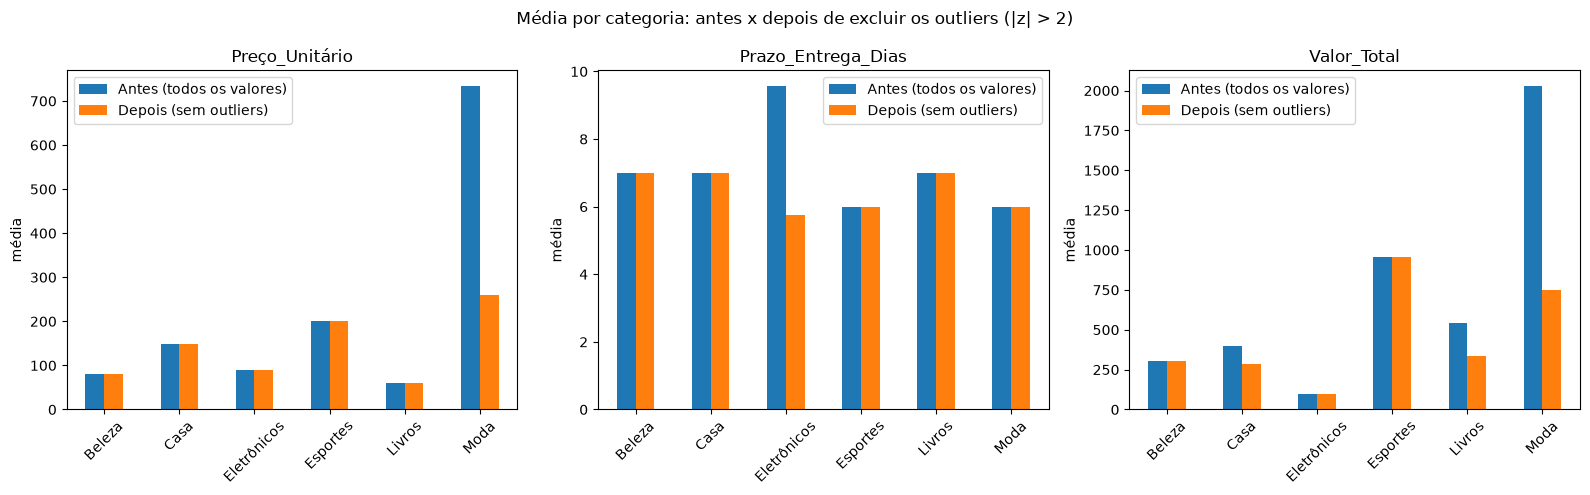

In [17]:
# médias por categoria antes x depois de retirar os outliers identificados pelo z-score
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, colunas_imputadas):
    pd.DataFrame({"Antes (todos os valores)": media_antes[col], "Depois (sem outliers)": media_depois[col]}).plot.bar(ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("média")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Média por categoria: antes x depois de excluir os outliers (|z| > 2)")
plt.tight_layout()
plt.show()

- **Identificação dos outliers:** o z-score calculado **dentro de cada categoria**, com limite |z| > 2, marcou exatamente os 4 pedidos já rotulados como anomalia na coluna `Situação_Anormal` (1012, 1027, 1043 e 1056). O limite clássico de |z| > 3 não detectou nenhum, pois com 10 pedidos por categoria o z-score máximo possível é ≈ 2,85.
- **Impacto nas médias:** os outliers distorciam as médias por categoria. Por exemplo, em Moda o `Preço_Unitário` médio cai de 732,90 para 258,79 (−64,7%) e, em Livros, o `Valor_Total` médio cai de 541,37 para 334,69 (−38,2%). Em 13 das 18 combinações categoria × coluna a média não mudou.
- **Impacto na imputação:** os valores faltantes foram preenchidos com a média da categoria calculada **sem os outliers**. Isso alterou a imputação do `Valor_Total` do pedido 1020 (Casa), de 397,66 para 285,47, e do `Prazo_Entrega_Dias` do pedido 1049 (Eletrônicos), de 9,56 para 5,75 dias. A `Forma_Pagamento` do pedido 1036 (Livros) foi preenchida com a moda da categoria (PIX), por ser uma variável de texto.
- **Ordem do tratamento:** aplicar o z-score antes de imputar evita que valores extremos contaminem o preenchimento dos faltantes. Sem essa etapa, a imputação usaria médias inflacionadas.
- **Bibliotecas:** pandas, `scipy.stats.zscore` (com `ddof=1`) e `StandardScaler` chegam à mesma conclusão sobre os outliers; a diferença está no desvio padrão usado (`ddof=1` no pandas, `ddof=0` por padrão no SciPy e no scikit-learn).
- **Limitações:** com apenas 10 pedidos por categoria, o z-score é pouco sensível e o próprio outlier infla o desvio padrão. Para bases maiores ou mais assimétricas, vale considerar o z-score modificado (mediana e MAD). Além disso, o `Valor_Total` imputado do pedido 1020 não é recalculado a partir de quantidade, preço, desconto e frete, então pode ficar inconsistente com esses campos.

## Referências conceituais
- Gauss (teoria dos erros), Pearson (desvio padrão), Fisher (inferência), Shewhart (controle de processos), Altman (1968), Iglewicz e Hoaglin (1993).